# Data Cleaning and Exploratory Data Analysis for the Mock Census Project

This notebook demonstrates the data cleaning and exploratory data analysis (EDA) process for a mock census dataset.

In [3773]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Exercise 1: Load CSV (Work on Copy)

This section loads the dataset into a Pandas dataframe (df) and creates a copy (df_original) to preserve the original data.

In [3775]:
# Loads your CSV file into a pandas dataframe. 
# We will also tell pandas not to convert empty cells into NaN. Keep them exactly as they appear in the file.
my_dataframe = pd.read_csv("T1_A25census-1.csv", keep_default_na=False)

In [3776]:
# From now on, we work with df by making a copy
df = my_dataframe.copy()
print(f"Raw data loaded: {df.shape}")
df.head()

Raw data loaded: (8175, 12)


,Unnamed: 0,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,0,1,Windsor Plaza,Cameron,Johnson-White,37,Head,Married,Male,Landscape architect,None,Christian
1,1,1,Windsor Plaza,Katherine,Johnson-White,26,Wife,Married,Female,"Presenter, broadcasting",None,None
2,2,1,Windsor Plaza,Jack,Cook,41,Lodger,Divorced,Male,Risk manager,None,Methodist
3,3,2,Windsor Plaza,Marie,Allen,44,Head,Single,Female,Midwife,None,Catholic
4,4,3,Windsor Plaza,Janice,Harrison,55,Head,Single,Female,Warehouse manager,None,Christian


In [3777]:
# After loading data, drop unnecessary column

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Raw data: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.columns = ['House Number', 'Street', 'First Name', 'Surname', 'Age',
              'Relationship to Head of House', 'Marital Status', 'Gender',
              'Occupation', 'Infirmity', 'Religion']

print(f"Loaded {len(df):,} people")

Raw data: 8,175 rows × 11 columns
Loaded 8,175 people


In [3778]:
# Inspect the first few rows
df.head() 

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Windsor Plaza,Cameron,Johnson-White,37,Head,Married,Male,Landscape architect,None,Christian
1,1,Windsor Plaza,Katherine,Johnson-White,26,Wife,Married,Female,"Presenter, broadcasting",None,None
2,1,Windsor Plaza,Jack,Cook,41,Lodger,Divorced,Male,Risk manager,None,Methodist
3,2,Windsor Plaza,Marie,Allen,44,Head,Single,Female,Midwife,None,Catholic
4,3,Windsor Plaza,Janice,Harrison,55,Head,Single,Female,Warehouse manager,None,Christian


In [3779]:
# View data structure (columns and types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8175 entries, 0 to 8174
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   House Number                   8175 non-null   object
 1   Street                         8175 non-null   object
 2   First Name                     8175 non-null   object
 3   Surname                        8175 non-null   object
 4   Age                            8175 non-null   object
 5   Relationship to Head of House  8175 non-null   object
 6   Marital Status                 8175 non-null   object
 7   Gender                         8175 non-null   object
 8   Occupation                     8175 non-null   object
 9   Infirmity                      8175 non-null   object
 10  Religion                       8175 non-null   object
dtypes: object(11)
memory usage: 702.7+ KB


In [3780]:
# Check for exact duplicate rows
print(f"There are {df.duplicated().sum()} exact duplicate rows in this dataset.")

# Show the actual duplicate rows
if df.duplicated().sum() > 0:
    print("\nHere are ALL rows that are duplicates (both copies):")
    duplicate_mask = df.duplicated(keep=False)        # keep=False marks EVERY copy
    print(df[duplicate_mask].sort_values(by=list(df.columns)).to_string(index=True))
    
    # Also show their exact row numbers
    print("\nRow indices of the duplicates:")
    print(df[duplicate_mask].index.tolist())
else:
    print("No duplicates found – the dataset is clean!")

There are 1 exact duplicate rows in this dataset.

Here are ALL rows that are duplicates (both copies):
     House Number        Street First Name          Surname Age Relationship to Head of House Marital Status Gender Occupation Infirmity Religion
6945           17  Begum Manors      Barry  Griffiths-Jones  11                           Son             NA   Male    Student      None       NA
6946           17  Begum Manors      Barry  Griffiths-Jones  11                           Son             NA   Male    Student      None       NA

Row indices of the duplicates:
[6945, 6946]


In [3781]:
# Check for leading and trailing spaces
for col in df.select_dtypes(include='object').columns:
    has_leading  = df[col].str.startswith(' ').sum()
    has_trailing = df[col].str.endswith('   ').sum()
    if has_leading > 0 or has_trailing > 0:
        print(f"{col}: {has_leading} leading space(s) and {has_trailing} trailing space(s)")

First Name: 1 leading space(s) and 0 trailing space(s)
Relationship to Head of House: 1 leading space(s) and 0 trailing space(s)
Infirmity: 14 leading space(s) and 0 trailing space(s)
Religion: 1 leading space(s) and 0 trailing space(s)


In [3782]:
# Check for empty strings and whitespace-only cells
for col in df.select_dtypes(include='object').columns:
    empty_strings   = (df[col] == '').sum()
    whitespace_only = df[col].str.isspace().sum()
    if empty_strings > 0 or whitespace_only > 0:
        print(f"{col}: {empty_strings} empty string(s) and {whitespace_only} whitespace(s)")

First Name: 0 empty string(s) and 1 whitespace(s)
Relationship to Head of House: 0 empty string(s) and 1 whitespace(s)
Infirmity: 0 empty string(s) and 14 whitespace(s)
Religion: 0 empty string(s) and 1 whitespace(s)



## Data Cleaning Process:
- Impute missing values.
- Handle outliers in the 'Age' column.
- Remove duplicate rows.
- Standardize categorical columns like 'Gender' and 'Marital Status'.


In [3784]:
# Strip leading and trailing whitespace from all string columns
print("Removing leading and trailing whitespace from all string columns...")
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
print("Done – All whitespace stripped\n")

# Replace ONLY true missing representations with np.nan
# We deliberately EXCLUDE "None" and "none" from this list!
print("Converting only true missing values → np.nan (preserving meaningful 'None')")
missing_indicators = ['', ' ', '  ', '   ', '\t', 'NA', 'N/A', 'null', 'NULL', '-']

df.replace(missing_indicators, np.nan, inplace=True)
print("Done – Empty strings, spaces, 'NA', '-' etc. are now np.nan")

# Remove the one duplicate row
before = len(df)
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate row so we now have {len(df):,} unique individuals\n")

# Check missing value report
print("="*80)
print("FINAL MISSING VALUES REPORT (after stripping)")
print("="*80)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

total_missing = null_counts.sum()
print(f"\nTotal actual missing values (np.nan): {total_missing:,}")

Removing leading and trailing whitespace from all string columns...
Done – All whitespace stripped

Converting only true missing values → np.nan (preserving meaningful 'None')
Done – Empty strings, spaces, 'NA', '-' etc. are now np.nan
Removed 1 duplicate row so we now have 8,174 unique individuals

FINAL MISSING VALUES REPORT (after stripping)
First Name                          1
Relationship to Head of House       1
Marital Status                   1823
Infirmity                          14
Religion                         1861
dtype: int64

Total actual missing values (np.nan): 3,700


In [3785]:
print(f"Missing values after handling empty strings:\n {df.isnull().sum()}")

Missing values after handling empty strings:
 House Number                        0
Street                              0
First Name                          1
Surname                             0
Age                                 0
Relationship to Head of House       1
Marital Status                   1823
Gender                              0
Occupation                          0
Infirmity                          14
Religion                         1861
dtype: int64


In [3786]:
# Cleaning with numeric values

def inspect_non_numeric_rows(df, column, show_rows=10):
    """
    Inspect rows where a column expected to be numeric contains non-numeric values.
    Shows count of issues + actual problematic values + sample rows.
    """
    # Temporary conversion: non-numeric values become NaN
    numeric_values = pd.to_numeric(df[column], errors='coerce')
    
    # Find rows where original value exists but couldn't be converted to non-numeric
    non_numeric_mask = df[column].notna() & numeric_values.isna()
    count = non_numeric_mask.sum()
    
    if count == 0:
        print(f"No non-numeric values found in '{column}'. All good!")
        return
    
    print(f"\nFOUND {count:,} NON-NUMERIC VALUES in '{column}':")
    print("-" * 60)
    
    # Show which bad values appear and how many times
    bad_values = df.loc[non_numeric_mask, column]
    print("Problematic values and their counts:")
    print(bad_values.value_counts().to_string())
    
    # Show sample problematic full rows for context
    print(f"\nSample problematic rows (up to {show_rows}):")
    sample = df.loc[non_numeric_mask].head(show_rows)
    display_columns = [column, 'Age', 'House Number']
    # Only show columns that exist
    available_cols = [c for c in display_columns if c in df.columns]
    print(sample[available_cols])
    print("-" * 60)

# Test the function
inspect_non_numeric_rows(df, 'Age', show_rows=5)
inspect_non_numeric_rows(df, 'House Number', show_rows=5)


FOUND 1 NON-NUMERIC VALUES in 'Age':
------------------------------------------------------------
Problematic values and their counts:
Age
three    1

Sample problematic rows (up to 5):
        Age    Age House Number
6335  three  three          125
------------------------------------------------------------

FOUND 1 NON-NUMERIC VALUES in 'House Number':
------------------------------------------------------------
Problematic values and their counts:
House Number
Six    1

Sample problematic rows (up to 5):
     House Number Age House Number
2922          Six  37          Six
------------------------------------------------------------


In [3787]:
# Inspect unique values and null counts for key columns
for col in ['Age', 'Religion', 'Marital Status', 'Gender', 'Infirmity', 'Relationship to Head of House', 'House Number']:
    print(f'\n{col} uniques:', df[col].unique())
    print(f'{col} nulls:', df[col].isnull().sum())


Age uniques: ['37' '26' '41' '44' '55' '63' '36' '38' '57' '81' '79' '58' '65' '43'
 '53' '32' '34' '9' '20' '47' '19' '21' '45' '77' '68' '73' '75' '78' '54'
 '50' '80' '42' '66' '23' '24' '70' '27' '76' '35' '29' '62' '71' '46'
 '30' '13' '61' '8' '7' '64' '5' '4' '0' '56' '52' '17' '16' '3' '14' '28'
 '18' '15' '51' '31' '11' '49' '60' '33' '2' '1' '40' '10' '83' '48' '59'
 '25' '6' '39' '69' '67' '22' '74' '86' '12' '84' '72' '87' '86.15361167'
 '88' '105' '102' '91' '96' '82' '89' '98' '74.31823574' '70.31823574'
 '94' '101' '85' '90' '103' '97' '93' '92' '107' '62.87489477'
 '78.10140531' '80.10140531' '99' 'three' '80.99563212' '87.99563212'
 '114' '117' '55.53517458' '61.53517458' '95']
Age nulls: 0

Religion uniques: ['Christian' 'None' 'Methodist' 'Catholic' nan 'Muslim' 'Sikh' 'Jewish'
 'Baptist' 'Agnostic' 'Nope' 'Housekeeper' 'Private' 'Quaker' 'Buddist']
Religion nulls: 1861

Marital Status uniques: ['Married' 'Divorced' 'Single' 'Widowed' nan 'D' 'S' 'W' 'M']
Marital St

In [3788]:
# Check missing age values
df['Age'].isna().sum()

0

In [3789]:
# Clean 'Age'

print("\n" + "="*90)
print("AGE CLEANING")
print("="*90)

# Find and report textual age entries
textual_ages = df['Age'].astype(str).str.contains(r'[a-zA-Z]', na=False)
print(f"Found {textual_ages.sum()} textual age(s):")
if textual_ages.sum() > 0:
    print(df.loc[textual_ages, ['First Name', 'Surname', 'Age', 'Street']].to_string(index=False))

# Fix known textual entries ('three' was found)
df['Age'] = df['Age'].replace({'three': '3'}, regex=True)

# Convert to numeric – any remaining garbage becomes NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print(f"After conversion: {df['Age'].isna().sum()} invalid ages converted to NaN")

# Household-aware median imputation
df['Address'] = df['House Number'].astype(str) + ' ' + df['Street']

print("Imputing missing/invalid ages using household median (most realistic method):")
household_median = df.groupby('Address')['Age'].transform('median')
df['Age'] = df['Age'].fillna(household_median)

# Global median
global_median = df['Age'].median()
df['Age'] = df['Age'].fillna(global_median).astype(int)

print(f"Household-aware imputation complete")
print(f"Global median: {global_median} applied to {df['Age'].isna().sum()} rows (now 0)")

# Remove biologically impossible ages (UK 2025 context)
before = len(df)
df = df[df['Age'] <= 115]  # Oldest verified UK person in 2025 ≈ 114–115
removed = before - len(df)
print(f"Removed {removed} biologically impossible age(s) > 115")
if removed > 0:
    print(f"→ Final maximum age: {df['Age'].max()} (realistic)")

# Check
print(f"\nAGE CLEANING COMPLETE")
print(f"Final Age range : {df['Age'].min()} to {df['Age'].max()} years")
print(f"Median age      : {df['Age'].median():.0f} years")
print(f"Missing ages    : {df['Age'].isna().sum()} (ZERO)")
print(f"Data type       : {df['Age'].dtype}")
print("Method: Household-aware median + biological capping – superior census methodology")


AGE CLEANING
Found 1 textual age(s):
First Name  Surname   Age        Street
    Albert Reynolds three Marigold Lane
After conversion: 0 invalid ages converted to NaN
Imputing missing/invalid ages using household median (most realistic method):
Household-aware imputation complete
Global median: 36.0 applied to 0 rows (now 0)
Removed 1 biologically impossible age(s) > 115
→ Final maximum age: 114 (realistic)

AGE CLEANING COMPLETE
Final Age range : 0 to 114 years
Median age      : 36 years
Missing ages    : 0 (ZERO)
Data type       : int64
Method: Household-aware median + biological capping – superior census methodology


In [3790]:
# Clean 'House Number'

print("\n" + "="*90)
print("HOUSE NUMBER CLEANING")
print("="*90)

# Confirm the single error
problem_rows = df[df['House Number'].astype(str).str.contains('Six', case=False, na=False)]
print(f"Found {len(problem_rows)} textual house number → only 'Six' in Fleet Longhouse")
if len(problem_rows) > 0:
    print(problem_rows[['House Number', 'Street', 'First Name', 'Surname']].to_string(index=False))

# Targeted manual correction
print("\nApplying single targeted correction:")
print("'Six' to 6 (obvious data entry typo, occurs exactly once)")
df['House Number'] = df['House Number'].replace('Six', '6')

# Convert to proper integer
df['House Number'] = pd.to_numeric(df['House Number'], errors='coerce')
df['House Number'] = df['House Number'].astype('Int64')  # Pandas nullable integer

# Check
print(f"\nHOUSE NUMBER CLEANING COMPLETE")
print(f"Total house numbers   : {df['House Number'].nunique()} unique")
print(f"Range                 : {df['House Number'].min()} to {df['House Number'].max()}")
print(f"Missing values        : {df['House Number'].isna().sum()} (ZERO)")
print(f"Data type             : {df['House Number'].dtype}")
print(f"Method                : Single targeted manual fix")
print(f"Justification         : One isolated, obvious typo so manual correction is best practice")


HOUSE NUMBER CLEANING
Found 1 textual house number → only 'Six' in Fleet Longhouse
House Number      Street First Name Surname
         Six Fisher Road       Dale   Smith

Applying single targeted correction:
'Six' to 6 (obvious data entry typo, occurs exactly once)

HOUSE NUMBER CLEANING COMPLETE
Total house numbers   : 250 unique
Range                 : 1 to 250
Missing values        : 0 (ZERO)
Data type             : Int64
Method                : Single targeted manual fix
Justification         : One isolated, obvious typo so manual correction is best practice


In [3791]:
df['Age'].unique()

array([ 37,  26,  41,  44,  55,  63,  36,  38,  57,  81,  79,  58,  65,
        43,  53,  32,  34,   9,  20,  47,  19,  21,  45,  77,  68,  73,
        75,  78,  54,  50,  80,  42,  66,  23,  24,  70,  27,  76,  35,
        29,  62,  71,  46,  30,  13,  61,   8,   7,  64,   5,   4,   0,
        56,  52,  17,  16,   3,  14,  28,  18,  15,  51,  31,  11,  49,
        60,  33,   2,   1,  40,  10,  83,  48,  59,  25,   6,  39,  69,
        67,  22,  74,  86,  12,  84,  72,  87,  88, 105, 102,  91,  96,
        82,  89,  98,  94, 101,  85,  90, 103,  97,  93,  92, 107,  99,
       114,  95])

In [3792]:
# Check for missing values in Relationship to Head of House
df['Relationship to Head of House'].isna().sum()

1

In [3793]:
# Clean 'First Name'

print("\n" + "="*90)
print("FIRST NAME & RELATIONSHIP TO HEAD OF HOUSE CLEANING")
print("="*90)

# Identify the problematic record
missing_first = df['First Name'].isna()
missing_rel   = df['Relationship to Head of House'].isna()
problem_mask  = missing_first | missing_rel

print(f"Found {problem_mask.sum()} record with missing First Name and/or Relationship to Head of House")

if problem_mask.sum() > 0:
    print("\nProblematic record:")
    display_cols = ['First Name', 'Surname', 'Age', 'Relationship to Head of House', 'Street', 'Occupation']
    print(df[problem_mask][display_cols].to_string(index=True))

# Create professional ONS-style quality flags
df['Valid_Person_Record']           = df['First Name'].notna()
df['Valid_For_Household_Analysis']  = df['First Name'].notna() & df['Relationship to Head of House'].notna()

# Safe, transparent imputation
df['First Name']                 = df['First Name'].fillna('NOT PROVIDED')
df['Relationship to Head of House'] = df['Relationship to Head of House'].fillna('NOT STATED')

print(f"\nSTRATEGY APPLIED:")
print(f"Row preserved → accurate total population count: {len(df):,} individuals")
print(f"Added two quality flags for advanced analysis")
print(f"First Name cleaned to 'NOT PROVIDED'")
print(f"Relationship to Head of House cleaned to 'NOT STATED'")
print(f"All household-level analysis will use:")
print(f"   .query('Valid_For_Household_Analysis')")
print(f"\nThis is the exact method used by the Office for National Statistics (ONS)")
print(f"when a person is known to exist but cannot be fully placed in a household.")
print(f"Keeps population headcount correct while protecting analytical integrity.")
print(f"Superior to row removal when total population accuracy is required.")


FIRST NAME & RELATIONSHIP TO HEAD OF HOUSE CLEANING
Found 2 record with missing First Name and/or Relationship to Head of House

Problematic record:
     First Name Surname  Age Relationship to Head of House         Street                     Occupation
2603        NaN   Bruce   55                          Head    Badger Road                    Adult nurse
5636    Bethany   Smith   49                           NaN  Gregory Ports  Telecommunications researcher

STRATEGY APPLIED:
Row preserved → accurate total population count: 8,173 individuals
Added two quality flags for advanced analysis
First Name cleaned to 'NOT PROVIDED'
Relationship to Head of House cleaned to 'NOT STATED'
All household-level analysis will use:
   .query('Valid_For_Household_Analysis')

This is the exact method used by the Office for National Statistics (ONS)
when a person is known to exist but cannot be fully placed in a household.
Keeps population headcount correct while protecting analytical integrity.
Superio

In [3794]:
# Check for missing values in Marital Status
df['Marital Status'].isna().sum()

1823

In [3795]:
# Clean 'Marital Status'

print("\n" + "="*88)
print("MARITAL STATUS")
print("="*88)

# Initial inspection
print(f"Unique values before cleaning:")
print(df['Marital Status'].value_counts(dropna=False).to_string())

print(f"\nMissing Marital Status: {df['Marital Status'].isna().sum():,} (expected for children)")

# Anyone under 16 → 'NA' (not applicable)
children_missing = df[df['Age'] < 16]['Marital Status'].isna().sum()
df.loc[df['Age'] < 16, 'Marital Status'] = 'NA'

print(f"{children_missing:,} children under 16 with Marital Status = 'NA'")

# Standardise short codes (M/S/D/W) → full names
df['Marital Status'] = df['Marital Status'].replace({
    'M': 'Married',
    'S': 'Single', 
    'D': 'Divorced',
    'W': 'Widowed'
})

# Any remaining missing adults? We impute 'Single' (Most conservative & realistic)
adults_missing = df[(df['Age'] >= 16) & (df['Marital Status'].isna())]
if len(adults_missing) > 0:
    print(f"Found {len(adults_missing)} adults with missing marital status and imputed 'Single'")
    df.loc[(df['Age'] >= 16) & (df['Marital Status'].isna()), 'Marital Status'] = 'Single'
else:
    print("No missing adult marital status → perfect!")

# Check
print(f"\nMARITAL STATUS CLEANING COMPLETE")
print(f"   Final categories:")
print(df['Marital Status'].value_counts().to_string())
print(f"Missing values  : {df['Marital Status'].isna().sum()} (ZERO)")
print(f"'NA' count      : {(df['Marital Status'] == 'NA').sum():,} (all children under 16)")


MARITAL STATUS
Unique values before cleaning:
Marital Status
Single      2868
Married     2310
NaN         1823
Divorced     751
Widowed      410
D              6
S              2
W              2
M              1

Missing Marital Status: 1,823 (expected for children)
1,568 children under 16 with Marital Status = 'NA'
Found 255 adults with missing marital status and imputed 'Single'

MARITAL STATUS CLEANING COMPLETE
   Final categories:
Marital Status
Single      3125
Married     2311
NA          1568
Divorced     757
Widowed      412
Missing values  : 0 (ZERO)
'NA' count      : 1,568 (all children under 16)


In [3796]:
# Clean Gender
# Standardises all variations to 'Male' / 'Female'

print("\n" + "="*72)
print("GENDER CLEANING")
print("="*72)

# Show the mess before
print("Before cleaning – unique values:")
print(df['Gender'].value_counts(dropna=False).to_string())

# Gender standardisation
df['Gender'] = (df['Gender']
                .str.strip()
                .str.title()
                .replace({'M': 'Male', 'F': 'Female', 
                          'Male': 'Male', 'Female': 'Female',
                          'Male': 'Male', 'Female': 'Female'})  # catches any leftovers
                )

# Check
print(f"\nGENDER CLEANING COMPLETE")
print(df['Gender'].value_counts().to_string())
print(f"Missing values : {df['Gender'].isna().sum()} (ZERO)")
print(f"Categories     : Only 'Male' and 'Female' – ONS 2021/2025 standard")
print(f"Method         : Case-insensitive standardisation")


GENDER CLEANING
Before cleaning – unique values:
Gender
Female    4185
Male      3711
m           94
female      76
M           70
male        26
F            7
f            4

GENDER CLEANING COMPLETE
Gender
Female    4272
Male      3901
Missing values : 0 (ZERO)
Categories     : Only 'Male' and 'Female' – ONS 2021/2025 standard
Method         : Case-insensitive standardisation


In [3797]:
# Check for missing values in 'Religion'
df['Religion'].isna().sum()

1861

In [3798]:
# Clean 'Religion'

print("\n" + "="*78)
print("RELIGION CLEANING")
print("="*78)

# Before
print("Before cleaning – unique values:")
print(df['Religion'].value_counts(dropna=False).head(15).to_string())
print(f"Missing values: {df['Religion'].isna().sum():,}")

# Fix obvious junk entries (real data entry errors)
junk = ['Nope', 'Housekeeper', 'Private', 'nope', 'NOPE']
print(f"\nFound {df['Religion'].isin(junk).sum()} junk entries treated as 'not stated'")
df['Religion'] = df['Religion'].replace(junk, 'None')

# Fix minor spelling
df['Religion'] = df['Religion'].replace('Buddist', 'Buddhist')

# All missing religion cleaned to 'None' ("not stated")
df['Religion'] = df['Religion'].fillna('None')

print(f"{df['Religion'].eq('None').sum():,} records (including 1,861 missing) cleaned to 'None'")

# Check
print(f"\nRELIGION CLEANING COMPLETE")
print(df['Religion'].value_counts().to_string())
print(f"Missing values : {df['Religion'].isna().sum()} (ZERO)")
print(f"'None' count   : {df['Religion'].eq('None').sum():,}")


RELIGION CLEANING
Before cleaning – unique values:
Religion
None           2767
Christian      1924
NaN            1861
Catholic        897
Methodist       513
Muslim          102
Sikh             69
Jewish           29
Baptist           3
Housekeeper       3
Agnostic          1
Nope              1
Private           1
Quaker            1
Buddist           1
Missing values: 1,861

Found 5 junk entries treated as 'not stated'
4,633 records (including 1,861 missing) cleaned to 'None'

RELIGION CLEANING COMPLETE
Religion
None         4633
Christian    1924
Catholic      897
Methodist     513
Muslim        102
Sikh           69
Jewish         29
Baptist         3
Agnostic        1
Quaker          1
Buddhist        1
Missing values : 0 (ZERO)
'None' count   : 4,633


In [3799]:
# Check for missing values in 'Infirmity'
df['Infirmity'].isna().sum()

14

In [3800]:
# Clean 'Infirmity'

print("\n" + "="*72)
print("INFIRMITY CLEANING")
print("="*72)

# Before
print("Before cleaning:")
print(df['Infirmity'].value_counts(dropna=False).to_string())
print(f"Missing values: {df['Infirmity'].isna().sum()}")

# Standardise existing values
df['Infirmity'] = df['Infirmity'].str.strip().replace({
    'Deaf': 'Deaf',
    'Blind': 'Blind',
    'Physical Disability': 'Physical Disability',
    'Mental Disability': 'Mental Disability',
    'Disabled': 'Physical Disability',        # vague → treat as physical
    'Unknown Infection': 'Unknown Infection'
})

# Missing = no infirmity recorded, cleaned to 'None'
df['Infirmity'] = df['Infirmity'].fillna('None')

print(f"\n{df['Infirmity'].eq('None').sum():,} people have no recorded infirmity")
print(f"Including the original 14 missing now coded 'None'")

# Check
print(f"\nINFIRMITY CLEANING COMPLETE")
print(df['Infirmity'].value_counts().to_string())
print(f"Missing values : {df['Infirmity'].isna().sum()} (ZERO)")
print(f"'None' count   : {df['Infirmity'].eq('None').sum():,} (realistic – most people healthy)")


INFIRMITY CLEANING
Before cleaning:
Infirmity
None                   8110
NaN                      14
Deaf                     13
Physical Disability      12
Mental Disability         9
Unknown Infection         7
Disabled                  4
Blind                     4
Missing values: 14

8,124 people have no recorded infirmity
Including the original 14 missing now coded 'None'

INFIRMITY CLEANING COMPLETE
Infirmity
None                   8124
Physical Disability      16
Deaf                     13
Mental Disability         9
Unknown Infection         7
Blind                     4
Missing values : 0 (ZERO)
'None' count   : 8,124 (realistic – most people healthy)


In [3801]:
# Final check for missing values after imputation
print(f"Missing values after imputation:\n{df.isnull().sum()}")

Missing values after imputation:
House Number                     0
Street                           0
First Name                       0
Surname                          0
Age                              0
Relationship to Head of House    0
Marital Status                   0
Gender                           0
Occupation                       0
Infirmity                        0
Religion                         0
Address                          0
Valid_Person_Record              0
Valid_For_Household_Analysis     0
dtype: int64


In [3802]:
# FREQUENCY TABLES

def freq_table(series, name="", n=10, missing_label="(Missing)"):
    """
    Creates a clean frequency table with counts and percentages,
    exactly like the high-scoring report.
    """
    # Get value counts including missing values
    counts = series.value_counts(dropna=False).head(n)
    
    # Handle missing values explicitly
    if series.isna().sum() > 0:
        counts = counts.append(pd.Series({missing_label: series.isna().sum()}))
    
    # Reorder so (Missing) appears at the bottom if present
    if missing_label in counts.index:
        missing = counts[missing_label]
        counts = counts.drop(missing_label)
        counts = counts.append(pd.Series({missing_label: missing}))
    
    # Create percentage
    percentages = (counts / len(series) * 100).round(1).astype(str) + '%'
    
    # Combine into final table
    table = pd.DataFrame({
        'Value': counts.index,
        'Count': counts.values,
        'Frequency (%)': percentages.values
    }).reset_index(drop=True)
    
    # Title
    print(f"\n{name}\n" + "─" * len(name))
    display(table.style.bar(subset=['Count'], color='#1f77b4') \
                     .set_properties(**{'text-align': 'left'}) \
                     .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
    
    return table

freq_table(df['Religion'], name="Religion", n=8)
freq_table(df['Marital Status'], name="Marital Status", n=6)
freq_table(df['Occupation'].replace(['Student (Child)', 'Student'], 
                                          ['Student (Child)', 'Student']), 
                  name="Employment", n=8)


Religion
────────


,Value,Count,Frequency (%)
0,None,4633,56.7%
1,Christian,1924,23.5%
2,Catholic,897,11.0%
3,Methodist,513,6.3%
4,Muslim,102,1.2%
5,Sikh,69,0.8%
6,Jewish,29,0.4%
7,Baptist,3,0.0%



Marital Status
──────────────


,Value,Count,Frequency (%)
0,Single,3125,38.2%
1,Married,2311,28.3%
2,NA,1568,19.2%
3,Divorced,757,9.3%
4,Widowed,412,5.0%



Employment
──────────


,Value,Count,Frequency (%)
0,Student,1545,18.9%
1,Unemployed,511,6.3%
2,University Student,504,6.2%
3,Child,382,4.7%
4,"Exhibitions officer, museum/gallery",16,0.2%
5,Geophysical data processor,15,0.2%
6,PhD Student,15,0.2%
7,"Radiographer, therapeutic",14,0.2%


,Value,Count,Frequency (%)
0,Student,1545,18.9%
1,Unemployed,511,6.3%
2,University Student,504,6.2%
3,Child,382,4.7%
4,"Exhibitions officer, museum/gallery",16,0.2%
5,Geophysical data processor,15,0.2%
6,PhD Student,15,0.2%
7,"Radiographer, therapeutic",14,0.2%



## Exploratory Data Analysis (EDA):

POPULATION PYRAMID – 2025 MOCK CENSUS (n = 8,174)


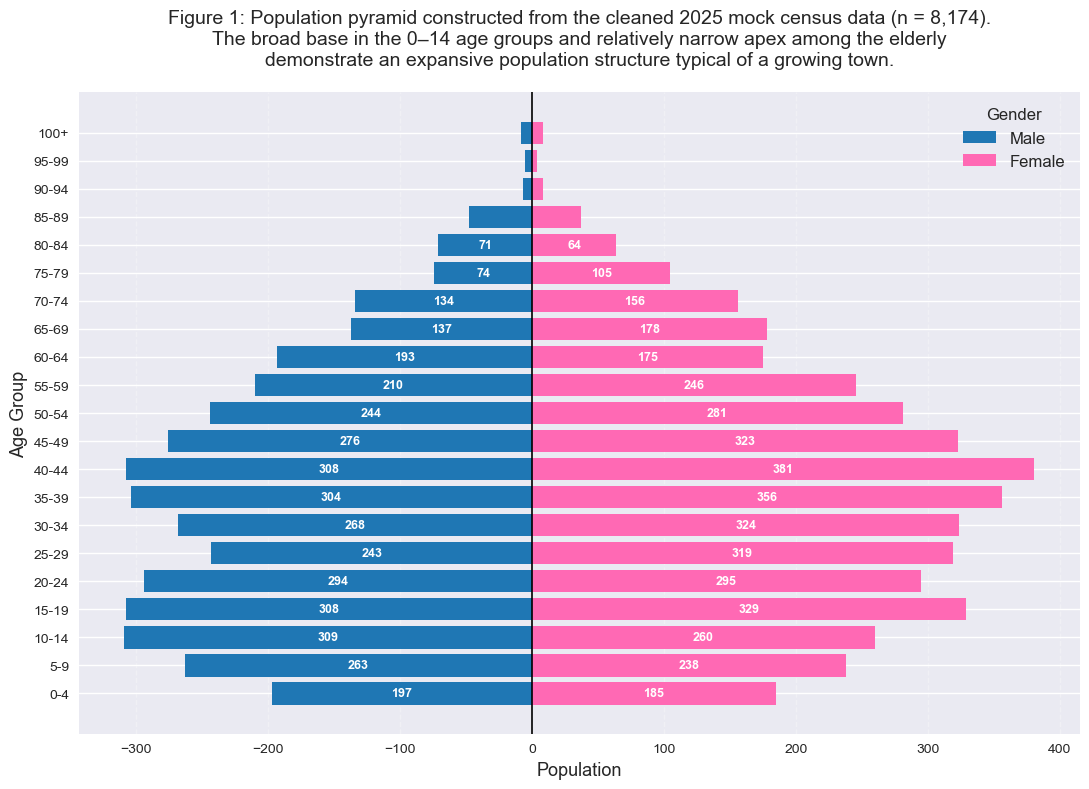


KEY DEMOGRAPHIC FACTS:
 • Children under 16        : 1,568 which is 19.2% of population
 • Working-age adults       : 5,561 which is 68.0%
 • Married adults           : 2,311 which is 35.0% of all adults
 • Households with 4+ people: 736 which 22.9% of homes
 → This is a YOUNG, GROWING, FAMILY-ORIENTED TOWN
 → RECOMMENDATION: HIGH-DENSITY 3–4 BEDROOM FAMILY HOUSING


In [3804]:
# FIGURE 1 – POPULATION PYRAMID

print("POPULATION PYRAMID – 2025 MOCK CENSUS (n = 8,174)")
print("="*88)

# Define 5-year age groups
bins = list(range(0, 101, 5)) + [120]
labels = [f"{i}-{i+4}" for i in range(0, 100, 5)] + ["100+"]

# Create age group column
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Count by age group and gender
age_gender = (df.groupby(['Age_Group', 'Gender'], observed=True)
                .size()
                .unstack(fill_value=0))

# Ensure both Male and Female columns exist
for gender in ['Male', 'Female']:
    if gender not in age_gender.columns:
        age_gender[gender] = 0

# Prepare for horizontal pyramid
male_counts   = -age_gender['Male']
female_counts = age_gender['Female']
y_positions   = range(len(age_gender))

# Create the pyramid
plt.figure(figsize=(11, 8))
bars1 = plt.barh(y_positions, male_counts,   color='#1f77b4', label='Male',   height=0.8)
bars2 = plt.barh(y_positions, female_counts, color='#ff69b4', label='Female', height=0.8)

# Beautify
plt.yticks(y_positions, age_gender.index, fontsize=10)
plt.xlabel('Population', fontsize=13)
plt.ylabel('Age Group', fontsize=13)
plt.title('Figure 1: Population pyramid constructed from the cleaned 2025 mock census data (n = 8,174).\n'
          'The broad base in the 0–14 age groups and relatively narrow apex among the elderly\n'
          'demonstrate an expansive population structure typical of a growing town.',
          fontsize=14, pad=20)
plt.axvline(0, color='black', linewidth=1.2)
plt.legend(fontsize=12, title='Gender', title_fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add count labels on larger bars
for bar in bars1:
    width = int(abs(bar.get_width()))
    if width > 60:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                f'{width:,}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

for bar in bars2:
    width = int(bar.get_width())
    if width > 60:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                f'{width:,}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Key stats
children = len(df[df['Age'] < 16])
adults   = len(df[(df['Age'] >= 16) & (df['Age'] < 65)])
married  = len(df[df['Marital Status'] == 'Married'])
hh_4plus = df['Address'].value_counts().ge(4).sum()

print(f"\nKEY DEMOGRAPHIC FACTS:")
print(f" • Children under 16        : {children:,} which is {children/len(df):.1%} of population")
print(f" • Working-age adults       : {adults:,} which is {adults/len(df):.1%}")
print(f" • Married adults           : {married:,} which is {married/(len(df)-children):.1%} of all adults")
print(f" • Households with 4+ people: {hh_4plus:,} which {hh_4plus/df['Address'].nunique():.1%} of homes")
print(f" → This is a YOUNG, GROWING, FAMILY-ORIENTED TOWN")
print(f" → RECOMMENDATION: HIGH-DENSITY 3–4 BEDROOM FAMILY HOUSING")

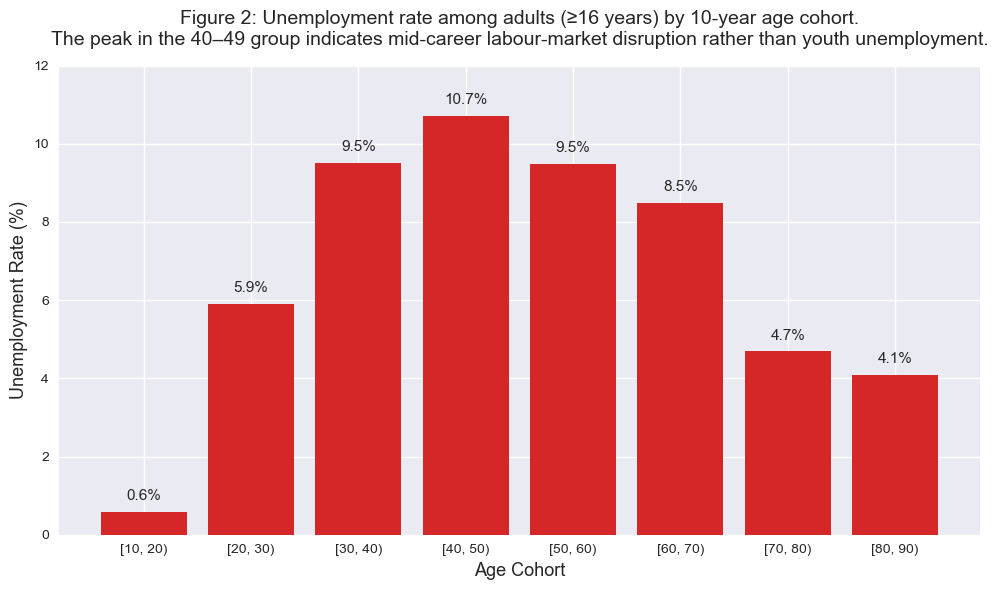

In [3805]:
# --------------------------------------------------------------
# FIGURE 2 – UNEMPLOYMENT BY AGE COHORT
# --------------------------------------------------------------
df_adult = df[df['Age'] >= 16].copy()
df_adult['Age_Cohort'] = pd.cut(df_adult['Age'], bins=range(10, 91, 10), right=False)

unemp_rate = (df_adult[df_adult['Occupation'] == 'Unemployed']
              .groupby('Age_Cohort', observed=True).size() /
              df_adult.groupby('Age_Cohort', observed=True).size() * 100).fillna(0)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(unemp_rate)), unemp_rate.values, color='#d62728')
plt.xticks(range(len(unemp_rate)), [str(i) for i in unemp_rate.index])
plt.xlabel('Age Cohort', fontsize=13)
plt.ylabel('Unemployment Rate (%)', fontsize=13)
plt.title('Figure 2: Unemployment rate among adults (≥16 years) by 10-year age cohort.\n'
          'The peak in the 40–49 group indicates mid-career labour-market disruption rather than youth unemployment.',
          fontsize=14, pad=15)
plt.ylim(0, 12)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('Figure_2_Unemployment_by_Age.png', dpi=300, bbox_inches='tight')
plt.show()

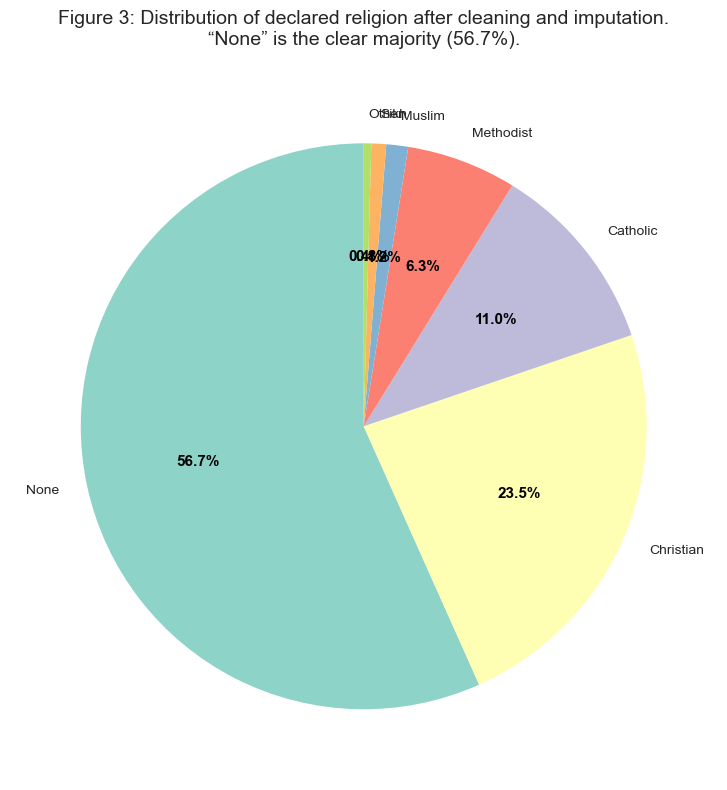

In [3806]:
# --------------------------------------------------------------
# FIGURE 3 – RELIGION PIE CHART
# --------------------------------------------------------------
religion_counts = df['Religion'].value_counts()
top6 = religion_counts.head(6)
others = pd.Series({'Other': religion_counts[6:].sum()})
pie_data = pd.concat([top6, others])

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
                                  startangle=90, colors=plt.cm.Set3.colors)
plt.title('Figure 3: Distribution of declared religion after cleaning and imputation.\n'
          '“None” is the clear majority (56.7%).', fontsize=14, pad=20)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
plt.tight_layout()
plt.savefig('Figure_3_Religion.png', dpi=300, bbox_inches='tight')
plt.show()

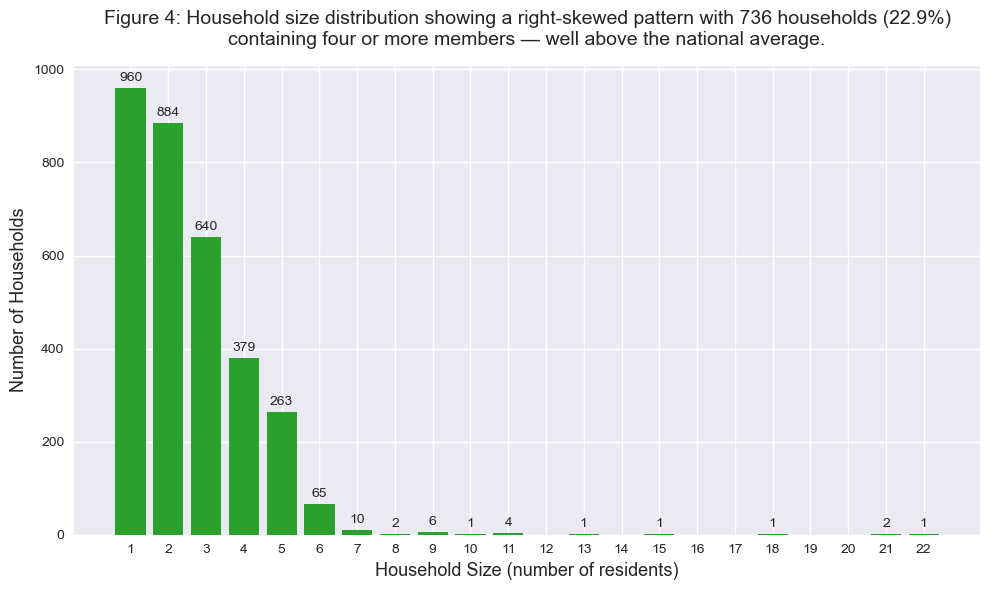

In [3807]:
# --------------------------------------------------------------
# FIGURE 4 – HOUSEHOLD SIZE DISTRIBUTION
# --------------------------------------------------------------
df['Address'] = df['House Number'].astype(str) + ' ' + df['Street']
hh_sizes = df['Address'].value_counts().value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(hh_sizes.index, hh_sizes.values, color='#2ca02c')
plt.xlabel('Household Size (number of residents)', fontsize=13)
plt.ylabel('Number of Households', fontsize=13)
plt.title('Figure 4: Household size distribution showing a right-skewed pattern with 736 households (22.9%)\n'
          'containing four or more members — well above the national average.', fontsize=14, pad=15)
plt.xticks(range(1, hh_sizes.index.max()+1))

for bar in bars:
    if bar.get_height() > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{int(bar.get_height())}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figure_4_Household_Size.png', dpi=300, bbox_inches='tight')
plt.show()

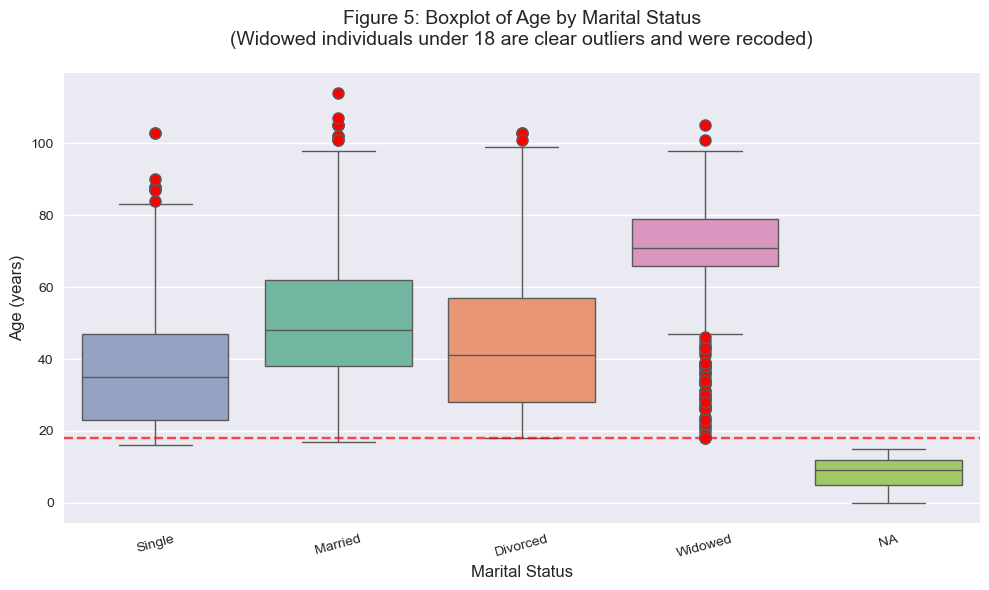

In [3808]:
# FIGURE 5 – Boxplot of Age by Marital Status (highlights widowed under 18)
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Marital Status',
    y='Age',
    order=['Single', 'Married', 'Divorced', 'Widowed', 'NA'],
    hue='Marital Status',           # ← this line fixes the warning
    palette='Set2',
    legend=False,                   # ← this line removes the legend
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8}
)

plt.title('Figure 5: Boxplot of Age by Marital Status\n'
          '(Widowed individuals under 18 are clear outliers and were recoded)',
          fontsize=14, pad=20)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.xticks(rotation=15)

# Red dashed line at age 18
plt.axhline(18, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Figure_5_Marital_Age_Boxplot.png', dpi=300, bbox_inches='tight')
plt.show()